In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import itertools
import seaborn as sns

In [2]:
data = pd.read_csv('401k_sampled.csv')

In [3]:
data.head(10)

,inc,e401,p401,net_tfa,tw
0,25388.084780,0,0,6935.821197,197125.283985
1,12905.363966,0,0,245.026541,197125.283985
2,71242.554256,0,0,245.026541,48828.306699
3,39277.398305,0,0,245.026541,12066.024203
4,25388.084780,0,0,-7384.978131,-2758.274708
5,71242.554256,1,1,72532.782574,197125.283985
6,25388.084780,1,0,245.026541,-2758.274708
7,71242.554256,0,0,72532.782574,197125.283985
8,12905.363966,0,0,72532.782574,48828.306699
9,25388.084780,0,0,6935.821197,12066.024203


In [4]:
def compute_px_z(data):

    # Get P(X = 1 | Z = 0) and P(X = 1 | Z = 1)
    p_x_z0 = np.mean(data[data['e401'] == 0]['p401'])
    p_x_z1 = np.mean(data[data['e401'] == 1]['p401'])

    return p_x_z0, p_x_z1

In [5]:
def compute_late(data):

    ey_z1 = np.mean(data[data['e401'] == 1]['tw'])
    ey_z0 = np.mean(data[data['e401'] == 0]['tw'])

    px_z0, px_z1 = compute_px_z(data)

    return (ey_z1 - ey_z0) / (px_z1 - px_z0)

In [6]:
def compute_cond_late(data):
    tfa_counts = data['net_tfa'].value_counts(normalize=True).sort_index()

    # Domain of financial assets
    tfa_vals = tfa_counts.index

    # Probability of financial assets
    tfa_probs = tfa_counts.values

    cond_late = 0

    for v, p in zip(tfa_vals, tfa_probs):
        cond_data = data[data['net_tfa'] == v] # Get the subdataset
        cond_late = cond_late + compute_late(cond_data) * p # Compute the conditional LATE

    return cond_late

In [7]:
# Compute P(Y = 1 | do(x, m))
def compute_py_xm(data, y, x, m):

    # Number of unique values of Y
    n_y = len(data['tw'].unique()) 

    # Initialize P(Y | X = x, M = m) = 0
    py_xm = 0
    
    # Get the unique values of eligibility
    z_vals = data['e401'].unique()

    for z in z_vals:
        # P(Z = z)
        pz = np.mean((data['e401'] == z)) 

        # No. of observations where Z = z, X = x, M = m
        zxm = np.sum((data['e401'] == z) & (data['p401'] == x) & (data['net_tfa'] == m)) + n_y

        # No. of observations where Z = z, M = m, X = x, Y = y
        y_zxm = np.sum((data['e401'] == z) & (data['p401'] == x) & (data['net_tfa'] == m) & (data['tw'] == y)) + 1

        py_xm = py_xm + (y_zxm / zxm) * pz

    return py_xm

# Compute P(Y = 1, z | do(x, m))
def compute_py_z_do(data, y, z, x, m):

    n_y = len(data['tw'].unique())

    yzxm = np.sum((data['e401'] == z) & (data['p401'] == x) & (data['net_tfa'] == m) & (data['tw'] == y)) + 1
    zxm = np.sum((data['e401'] == z) & (data['p401'] == x) & (data['net_tfa'] == m)) + n_y

    pz = np.mean((data['e401'] == z))

    return (yzxm / zxm) * pz

# Compute P(m, x | Z)
def compute_pmx_z(data, m, x):

    # Number of unique values of M and X
    n_m = len(data['net_tfa'].unique())
    n_x = len(data['p401'].unique())

    z0 = data[data['e401'] == 0]
    z1 = data[data['e401'] == 1]

    pmx_z0 = (np.sum((z0['p401'] == x) & (z0['net_tfa'] == m))) / (z0.shape[0]) # + n_m * n_x
    pmx_z1 = (np.sum((z1['p401'] == x) & (z1['net_tfa'] == m))) / (z1.shape[0]) # + n_m * n_x

    return pmx_z0, pmx_z1

# Compute E[Y_{x_1} - Y_{x_0} | X_{z_0} = 0, X_{z_1} = 1]
def compute_true_late(data):

    true_late = 0
    y_vals = data['tw'].unique()
    m_vals = data['net_tfa'].unique()

    ey_x1 = 0
    ey_x0 = 0

    px_z0, px_z1 = compute_px_z(data)

    for y in y_vals:

        # Compute P(Y_{x_1} = y | c_x) and P(Y_{x_0} = y | c_x)
        for m in m_vals:

            # x = 1
            pmx_z0, pmx_z1 = compute_pmx_z(data, m, 1)
            py_xm = compute_py_xm(data, y, 1, m)
            ey_x1 = ey_x1 + y * py_xm * ((pmx_z1 - pmx_z0) / (px_z1 - px_z0))

            # x = 0
            pmx_z0, pmx_z1 = compute_pmx_z(data, m, 0)
            py_xm = compute_py_xm(data, y, 0, m)
            ey_x0 = ey_x0 + y * py_xm * ((pmx_z0 - pmx_z1) / (px_z1 - px_z0))
    
    true_late = ey_x1 - ey_x0

    return true_late
            

In [8]:
simple_late = data.groupby('inc').apply(compute_late)
cond_late = data.groupby('inc').apply(compute_cond_late)
true_late = data.groupby('inc').apply(compute_true_late)

In [9]:
print('Simple LATE:', simple_late)
print('Conditional LATE:', cond_late)
print('True LATE:', true_late)

Simple LATE: inc
12905.363966    17847.478173
25388.084780     8399.562125
39277.398305    15821.878802
71242.554256    23424.276178
dtype: float64
Conditional LATE: inc
12905.363966     3779.814649
25388.084780    -8225.740398
39277.398305    -5763.081541
71242.554256   -10853.562102
dtype: float64
True LATE: inc
12905.363966    37005.679901
25388.084780    19635.391277
39277.398305     7351.682968
71242.554256    -3954.713405
dtype: float64


In [10]:
truth = pd.read_pickle('401k_effect.pkl')

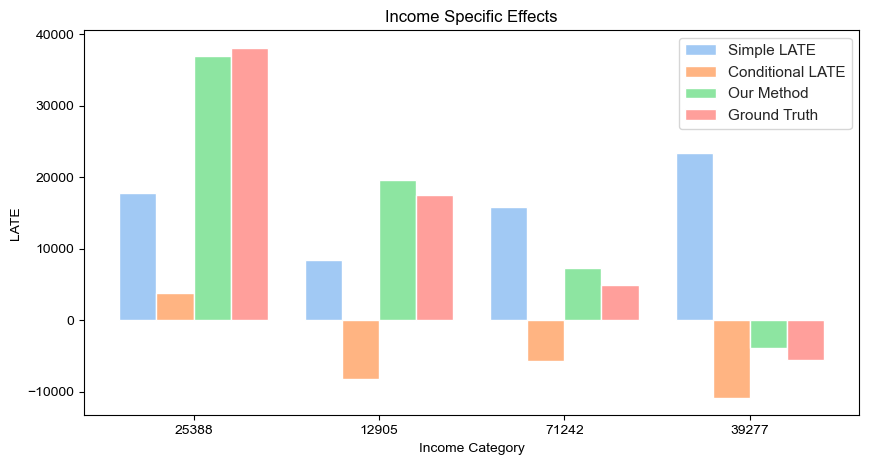

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))

width = 0.3  # the width of the bars
padding = 0.3  # the padding between sets of bars
labels = data['inc'].unique().astype(int)
wx = np.arange(len(labels)) * (4 * width + padding)  # position for each set of bars

# Set the Seaborn color palette
sns.set(style="whitegrid")
palette = sns.color_palette("pastel")

# Plotting the bars with increased distance between collections
rects1 = ax.bar(wx - 1.5*width, simple_late, width, label='Simple LATE', color=palette[0])
rects2 = ax.bar(wx - 0.5*width, cond_late, width, label='Conditional LATE', color=palette[1])
rects3 = ax.bar(wx + 0.5*width, true_late, width, label='Our Method', color=palette[2])
rects4 = ax.bar(wx + 1.5*width, truth, width, label='Ground Truth', color=palette[3])

# Adding labels, title, and legend
ax.set_xlabel('Income Category')
ax.set_ylabel('LATE')
ax.set_title('Income Specific Effects')
ax.set_xticks(wx)
ax.set_xticklabels(labels)
ax.legend()

In [12]:
simple_late

inc
12905.363966    17847.478173
25388.084780     8399.562125
39277.398305    15821.878802
71242.554256    23424.276178
dtype: float64

In [13]:
boostrap_n = 100

simple_late_samples = {cat:[] for cat in simple_late.index}
cond_late_samples = {cat:[] for cat in cond_late.index}
true_late_samples = {cat:[] for cat in true_late.index}

for _ in range(boostrap_n):
    sample = data.sample(frac=1, replace=True)

    simple_late_ = sample.groupby('inc').apply(compute_late)
    cond_late_ = sample.groupby('inc').apply(compute_cond_late)
    true_late_ = sample.groupby('inc').apply(compute_true_late)

    for cat in simple_late.index:
        simple_late_samples[cat].append(simple_late_[cat])
        cond_late_samples[cat].append(cond_late_[cat])
        true_late_samples[cat].append(true_late_[cat])

In [14]:
ci_simple_late = {}
for cat, val in simple_late_samples.items():
    ci_simple_late[cat] = (np.percentile(val, 2.5), np.percentile(val, 97.5))

ci_cond_late = {}
for cat, val in cond_late_samples.items():
    ci_cond_late[cat] = (np.percentile(val, 2.5), np.percentile(val, 97.5))

ci_true_late = {}
for cat, val in true_late_samples.items():
    ci_true_late[cat] = np.percentile(val, [2.5, 97.5])

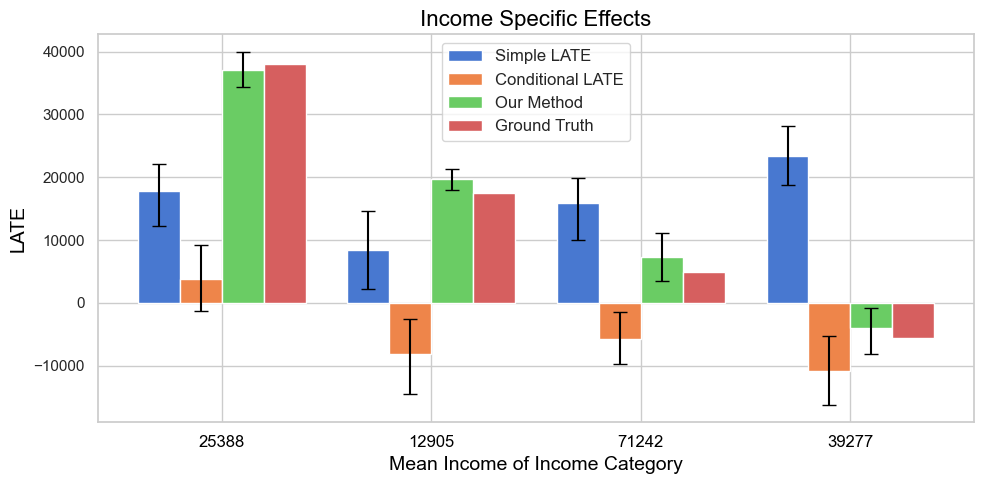

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))

width = 0.3  # the width of the bars
padding = 0.3  # the padding between sets of bars
labels = data['inc'].unique()
wx = np.arange(len(labels)) * (4 * width + padding)  # position for each set of bars

# Set the Seaborn color palette
sns.set(style="whitegrid")
palette = sns.color_palette("muted")

# Plotting the bars with increased distance between collections
rects1 = ax.bar(wx - 1.5*width, simple_late, width, label='Simple LATE', color=palette[0])
rects2 = ax.bar(wx - 0.5*width, cond_late, width, label='Conditional LATE', color=palette[1])
rects3 = ax.bar(wx + 0.5*width, true_late, width, label='Our Method', color=palette[2])
rects4 = ax.bar(wx + 1.5*width, truth, width, label='Ground Truth', color=palette[3])

# Adding error bars (confidence intervals)
ax.errorbar(wx - 1.5*width, simple_late.values, 
            yerr=[[simple_late[cat] - ci_simple_late[cat][0] for cat in labels], 
                  [ci_simple_late[cat][1] - simple_late[cat] for cat in labels]], 
            fmt='none', capsize=5, color='black')

ax.errorbar(wx - 0.5*width, cond_late.values, 
            yerr=[[cond_late[cat] - ci_cond_late[cat][0] for cat in labels], 
                  [ci_cond_late[cat][1] - cond_late[cat] for cat in labels]], 
            fmt='none', capsize=5, color='black')

ax.errorbar(wx + 0.5*width, true_late.values, 
            yerr=[[true_late[cat] - ci_true_late[cat][0] for cat in labels], 
                  [ci_true_late[cat][1] - true_late[cat] for cat in labels]], 
            fmt='none', capsize=5, color='black')

# Customizing labels, title, and legend
ax.set_xlabel('Mean Income of Income Category', fontsize=14, color='black')
ax.set_ylabel('LATE', fontsize=14, color='black')
ax.set_title('Income Specific Effects', fontsize=16, color='black')
ax.set_xticks(wx)
ax.set_xticklabels(labels.astype(int), fontsize=12, color='black')
ax.legend(fontsize=12)

# Improve the layout
plt.tight_layout()

# Save the plot as a PDF
plt.savefig('real-data.pdf')

# Show the plot
plt.show()